# **MODELE PRES-ENRAINE VGG16**



**Importation du data sous forme de .zip**

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving dataset2-master.zip to dataset2-master.zip


***Extraction de contenu de fichier dataset2-master.zip***

In [ ]:
!unzip dataset2-master.zip

Streaming output truncated to the last 5000 lines.
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8283.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8324.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8379.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8577.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8587.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8655.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8701.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_872.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8864.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8931.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8989.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_899.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_9320.jpeg  
  inflating: dataset2-master/images/TRAIN/LYMPHOCYTE/_9_9338.jpeg  

***Lister le contenu du fichier***

In [ ]:
!ls

dataset2-master  dataset2-master.zip  sample_data


***Importation du bibliothèque***

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

***Sppliting de data***

In [ ]:
path = "/content/dataset2-master/images"
print(path)

/content/dataset2-master/images


In [ ]:
print(os.listdir("/content/dataset2-master"))

['labels.csv', 'images']


In [ ]:
train_dir = path + "/TRAIN"
test_dir = path + "/TEST"

***Distribution des classes-Train/Test***

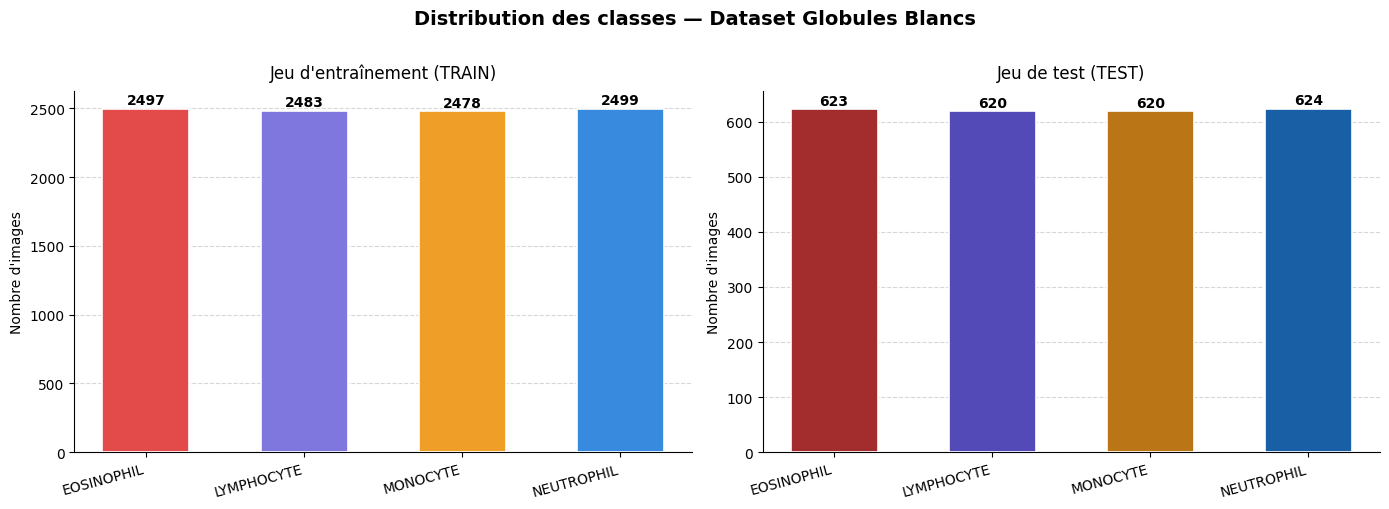

In [ ]:
# ── Couleurs par classe ──────────────────────────────────────────────────────
classes      = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
colors_train = ['#E24B4A', '#7F77DD', '#EF9F27', '#378ADD']
colors_test  = ['#A32D2D', '#534AB7', '#BA7517', '#185FA5']

def count_classes(directory, classes):
    counts = []
    for cls in classes:
        path = os.path.join(directory, cls)
        if os.path.exists(path):
            counts.append(len(os.listdir(path)))
        else:
            counts.append(0)
    return counts

train_counts = count_classes(train_dir, classes)
test_counts  = count_classes(test_dir,  classes)

x = np.arange(len(classes))
width = 0.38

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution des classes — Dataset Globules Blancs', fontsize=14, fontweight='bold', y=1.01)

# ── Train ────────────────────────────────────────────────────────────────────
bars_train = axes[0].bar(x, train_counts, color=colors_train, width=0.55,
                         edgecolor='white', linewidth=1.2, zorder=3)
axes[0].set_title('Jeu d\'entraînement (TRAIN)', fontsize=12, pad=10)
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes, rotation=15, ha='right', fontsize=10)
axes[0].set_ylabel('Nombre d\'images', fontsize=10)
axes[0].yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
axes[0].set_axisbelow(True)
axes[0].spines[['top', 'right']].set_visible(False)

for bar, count in zip(bars_train, train_counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                 str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

# ── Test ─────────────────────────────────────────────────────────────────────
bars_test = axes[1].bar(x, test_counts, color=colors_test, width=0.55,
                        edgecolor='white', linewidth=1.2, zorder=3)
axes[1].set_title('Jeu de test (TEST)', fontsize=12, pad=10)
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes, rotation=15, ha='right', fontsize=10)
axes[1].set_ylabel('Nombre d\'images', fontsize=10)
axes[1].yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
axes[1].set_axisbelow(True)
axes[1].spines[['top', 'right']].set_visible(False)

for bar, count in zip(bars_test, test_counts):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 str(count), ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## *Création de l'ImageDataGenerator pour train*

In [ ]:
train_datagenVGG16 = ImageDataGenerator(
    preprocessing_function=vgg16_preprocess,
    validation_split=0.2,
    ## Augmentation
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
)

**Générateur d'entraînement**

In [ ]:
train_generator = train_datagenVGG16.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

Found 7968 images belonging to 4 classes.


**Générateur de validation**

In [ ]:
val_generator = train_datagenVGG16.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 1989 images belonging to 4 classes.


***Création du générateur de test***

In [ ]:
test_datagenVGG16 = ImageDataGenerator(
    preprocessing_function=vgg16_preprocess
)

test_generator = test_datagenVGG16.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2487 images belonging to 4 classes.


**Chargement de VGG16 pré-entraîné**

In [ ]:
vgg16_base = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Geler tout le backbone sauf les 4 dernières couches conv
for layer in vgg16_base.layers[:-4]:
    layer.trainable = False

for layer in vgg16_base.layers[-4:]:
    layer.trainable = True

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


***Création du modèle***

In [ ]:
vgg16_model = Sequential([

    vgg16_base,

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(4, activation='softmax')
])

***Compilation du modèle vgg16_model***

In [ ]:
vgg16_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

***Entrainement du modèle vgg16_model***

In [ ]:
history_vgg16 = vgg16_model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator
)

Epoch 1/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 166s 597ms/step - accuracy: 0.4344 - loss: 1.1924 - val_accuracy: 0.6491 - val_loss: 0.8566
Epoch 2/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 140s 561ms/step - accuracy: 0.8055 - loss: 0.4827 - val_accuracy: 0.8748 - val_loss: 0.2943
Epoch 3/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 155s 622ms/step - accuracy: 0.9291 - loss: 0.1824 - val_accuracy: 0.9512 - val_loss: 0.1449
Epoch 4/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 144s 579ms/step - accuracy: 0.9596 - loss: 0.1130 - val_accuracy: 0.9779 - val_loss: 0.0558
Epoch 5/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 159s 639ms/step - accuracy: 0.9753 - loss: 0.0720 - val_accuracy: 0.9794 - val_loss: 0.0615
Epoch 6/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 143s 575ms/step - accuracy: 0.9794 - loss: 0.0548 - val_accuracy: 0.9879 - val_loss: 0.0344
Epoch 7/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 145s 581ms/step - accuracy: 0.9831 - loss: 0.0504 - val_accuracy: 0.9849 - val_loss: 0.0330
Epoch 8/15
249/249 ━━━━━━━━━━━━━━━━━━━━ 141s 566ms/step - accuracy: 0.9910 -

***Evaluation du modèle vgg16_model***

In [ ]:
loss_vgg16, acc_vgg16 = vgg16_model.evaluate(test_generator)

print(f"VGG16 Accuracy : {acc_vgg16*100:.2f}%")

print(f"VGG16 Loss : {loss_vgg16:.4f}")

78/78 ━━━━━━━━━━━━━━━━━━━━ 24s 311ms/step - accuracy: 0.8717 - loss: 1.0193
VGG16 Accuracy : 87.17%
VGG16 Loss : 1.0193


***Courbe de l'accuracy et Loss***

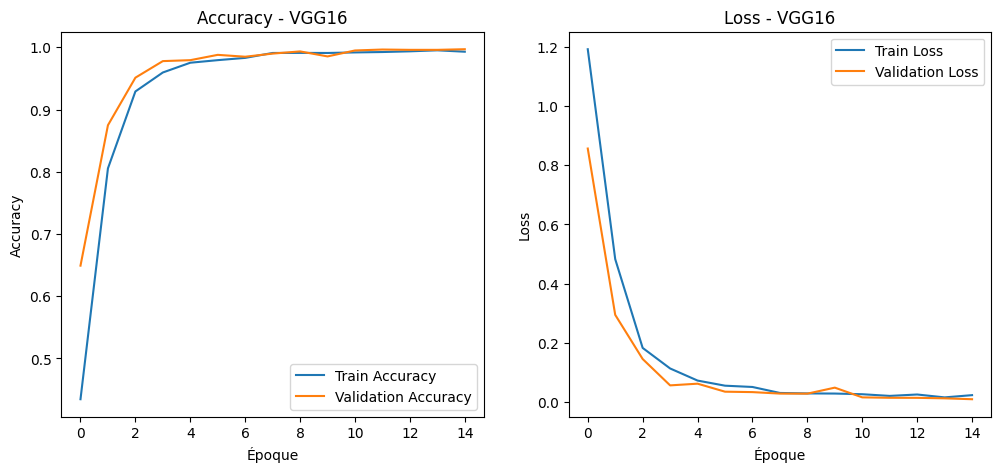

In [ ]:
def plot_training_curves(history, model_name):

    plt.figure(figsize=(12, 5))

    # Précision
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'Accuracy - {model_name}')
    plt.xlabel('Époque')
    plt.ylabel('Accuracy')
    plt.legend()

    # Perte
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'Loss - {model_name}')
    plt.xlabel('Époque')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()
plot_training_curves(history_vgg16, "VGG16")


**Performance du modèle**

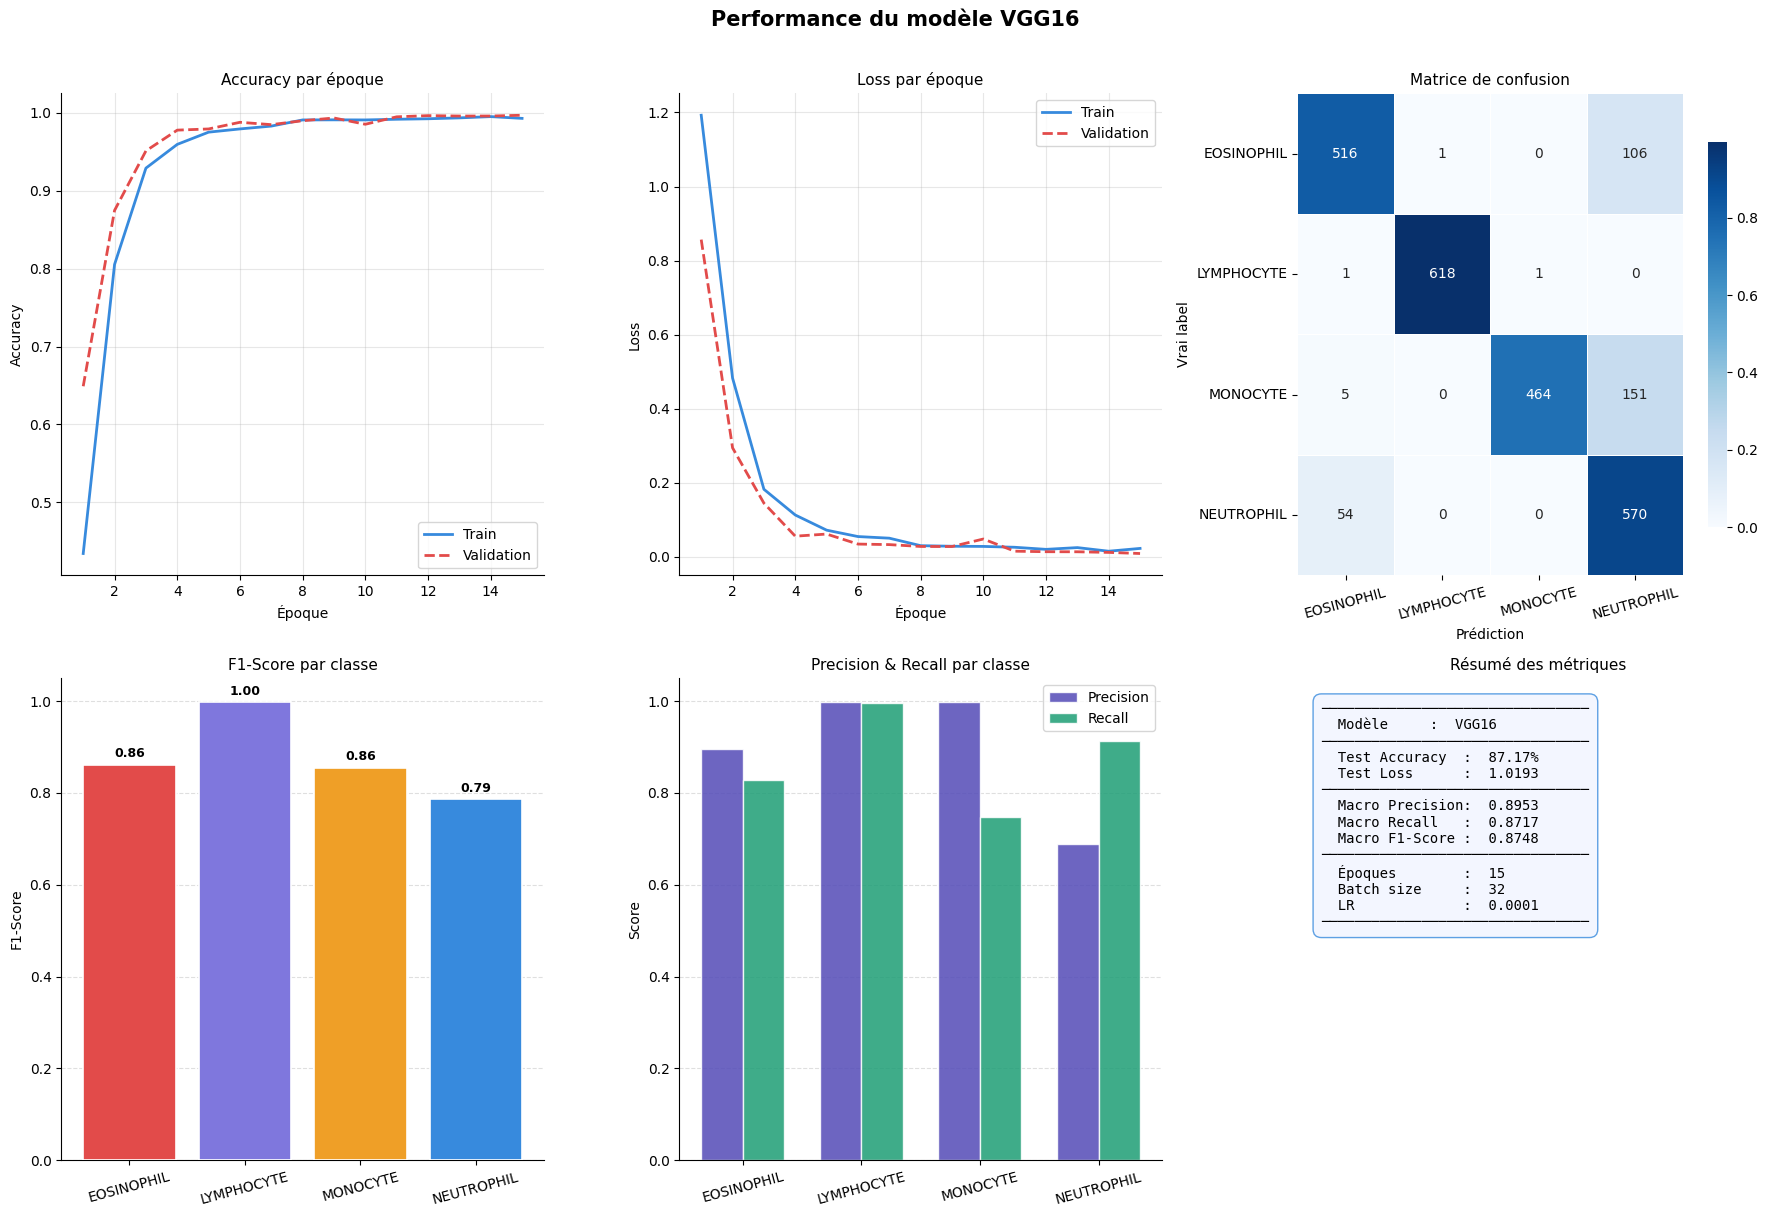

In [ ]:
def plot_all_metrics(history, model, test_generator, classes, model_name="VGG16"):

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle(f'Performance du modèle {model_name}', fontsize=15, fontweight='bold', y=1.01)

    # ── Palette ──────────────────────────────────
    color_train = '#378ADD'   # bleu
    color_val   = '#E24B4A'   # rouge

    epochs = range(1, len(history.history['accuracy']) + 1)

    # ── 1. Accuracy ───────────────────────────────────────────────────────────
    ax1 = fig.add_subplot(2, 3, 1)
    ax1.plot(epochs, history.history['accuracy'],     color=color_train, lw=2, label='Train')
    ax1.plot(epochs, history.history['val_accuracy'], color=color_val,   lw=2, label='Validation', linestyle='--')
    ax1.set_title('Accuracy par époque', fontsize=11)
    ax1.set_xlabel('Époque'); ax1.set_ylabel('Accuracy')
    ax1.legend(); ax1.grid(alpha=0.3)
    ax1.spines[['top', 'right']].set_visible(False)

    # ── 2. Loss ───────────────────────────────────────────────────────────────
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(epochs, history.history['loss'],     color=color_train, lw=2, label='Train')
    ax2.plot(epochs, history.history['val_loss'], color=color_val,   lw=2, label='Validation', linestyle='--')
    ax2.set_title('Loss par époque', fontsize=11)
    ax2.set_xlabel('Époque'); ax2.set_ylabel('Loss')
    ax2.legend(); ax2.grid(alpha=0.3)
    ax2.spines[['top', 'right']].set_visible(False)

    # ── 3. Matrice de confusion ───────────────────────────────────────────────
    ax3 = fig.add_subplot(2, 3, 3)
    test_generator.reset()
    y_pred  = np.argmax(model.predict(test_generator, verbose=0), axis=1)
    y_true  = test_generator.classes

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # normalisée

    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, ax=ax3, cbar_kws={'shrink': 0.8})
    ax3.set_title('Matrice de confusion', fontsize=11)
    ax3.set_xlabel('Prédiction'); ax3.set_ylabel('Vrai label')
    ax3.tick_params(axis='x', rotation=15)
    ax3.tick_params(axis='y', rotation=0)

    # ── 4. F1-Score par classe ────────────────────────────────────────────────
    ax4 = fig.add_subplot(2, 3, 4)
    report = classification_report(y_true, y_pred, target_names=classes, output_dict=True)
    f1_scores  = [report[cls]['f1-score']  for cls in classes]
    precisions = [report[cls]['precision'] for cls in classes]
    recalls    = [report[cls]['recall']    for cls in classes]

    colors_cls = ['#E24B4A', '#7F77DD', '#EF9F27', '#378ADD']
    bars = ax4.bar(classes, f1_scores, color=colors_cls, edgecolor='white', linewidth=1.2, zorder=3)
    ax4.set_title('F1-Score par classe', fontsize=11)
    ax4.set_ylabel('F1-Score'); ax4.set_ylim(0, 1.05)
    ax4.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax4.set_axisbelow(True)
    ax4.spines[['top', 'right']].set_visible(False)
    ax4.tick_params(axis='x', rotation=15)
    for bar, score in zip(bars, f1_scores):
        ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{score:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # ── 5. Precision / Recall par classe ──────────────────────────────────────
    ax5 = fig.add_subplot(2, 3, 5)
    x_pos = np.arange(len(classes))
    w = 0.35
    b1 = ax5.bar(x_pos - w/2, precisions, width=w, label='Precision',
                 color='#534AB7', alpha=0.85, edgecolor='white')
    b2 = ax5.bar(x_pos + w/2, recalls,    width=w, label='Recall',
                 color='#1D9E75', alpha=0.85, edgecolor='white')
    ax5.set_title('Precision & Recall par classe', fontsize=11)
    ax5.set_xticks(x_pos); ax5.set_xticklabels(classes, rotation=15)
    ax5.set_ylabel('Score'); ax5.set_ylim(0, 1.05)
    ax5.legend(); ax5.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax5.set_axisbelow(True)
    ax5.spines[['top', 'right']].set_visible(False)

    # ── 6. Résumé métriques globales ──────────────────────────────────────────
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')

    loss_val, acc_val = model.evaluate(test_generator, verbose=0)
    macro_f1  = report['macro avg']['f1-score']
    macro_pre = report['macro avg']['precision']
    macro_rec = report['macro avg']['recall']

    metrics_text = (
        f"{'─'*32}\n"
        f"  Modèle     :  {model_name}\n"
        f"{'─'*32}\n"
        f"  Test Accuracy  :  {acc_val*100:.2f}%\n"
        f"  Test Loss      :  {loss_val:.4f}\n"
        f"{'─'*32}\n"
        f"  Macro Precision:  {macro_pre:.4f}\n"
        f"  Macro Recall   :  {macro_rec:.4f}\n"
        f"  Macro F1-Score :  {macro_f1:.4f}\n"
        f"{'─'*32}\n"
        f"  Époques        :  {len(epochs)}\n"
        f"  Batch size     :  32\n"
        f"  LR             :  0.0001\n"
        f"{'─'*32}"
    )
    ax6.text(0.05, 0.95, metrics_text, transform=ax6.transAxes,
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round,pad=0.6', facecolor='#f0f4ff', edgecolor='#378ADD', alpha=0.8))
    ax6.set_title('Résumé des métriques', fontsize=11)

    plt.tight_layout()
    plt.savefig(f'performance_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ── Appel ────────────────────────────────────────────────────────────────────
plot_all_metrics(history_vgg16, vgg16_model, test_generator,
                 classes=['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL'],
                 model_name="VGG16")

# **Prédire la classe d'une image :**

In [ ]:
image = files.upload()

Saving monocyte.png to monocyte.png


In [ ]:
from PIL import Image
import numpy as np
import io

class_names = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']  # ← ici

filename = list(image.keys())[0]
img = Image.open(io.BytesIO(image[filename])).convert('RGB')
img_array = vgg16_preprocess(np.expand_dims(np.array(img.resize((224, 224)), dtype=np.float32), axis=0))

predictions = vgg16_model.predict(img_array)
pred_label  = class_names[np.argmax(predictions[0])]
confidence  = np.max(predictions[0]) * 100

print(f"Classe prédite : {pred_label} ({confidence:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Classe prédite : NEUTROPHIL (97.20%)


***Téléchargement du modèle au format .h5***

In [ ]:
vgg16_model.save("vgg16.h5")
from google.colab import files
files.download("vgg16.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>